In [1]:
# import necessary libraries
import pandas as pd
import pandas as pd
import numpy as np
import ast
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
playerMatchDetailsPerformanceDF = pd.read_csv('../aggregateMatchAndTimelineLarge.csv')
summonerRanksDF = pd.read_csv('../summonerRanksLarge.csv')
summonerRanksDF = summonerRanksDF[['summonerId', 'queueType', 'tier', 'rank', 'leaguePoints']] # just selecting necessary sets of data

print(playerMatchDetailsPerformanceDF.shape)
print(summonerRanksDF.shape)

for aCol in playerMatchDetailsPerformanceDF.columns:
    print(aCol)

print("-------------------------------")
for rCol in summonerRanksDF.columns:
    print(rCol)

(204990, 29)
(85758, 5)
gameId
gameDuration
puuid
summonerId
teamId
win
teamPosition
champExperience
kills
assists
turretKills
epicMonsterKills
visionScore
visionWardsBoughtInGame
magicDamageDealtToChampions
deaths
totalMinionsKilled
timeCCingOthers
totalDamageTaken
totalHealsOnTeammates
totalTimeSpentDead
goldEarned
objectivesStolen
objectivesStolenAssists
participantId
participantsAssisted
towerKillsAssisted
monsterKillsAssisted
participantsAssistedWithPressure
-------------------------------
summonerId
queueType
tier
rank
leaguePoints


In [3]:
# join summonerRanks with aggregateMatchDF
playerMatchDetailsPerformanceWithRanksDF = playerMatchDetailsPerformanceDF.merge(summonerRanksDF, on='summonerId', how='inner')
print(playerMatchDetailsPerformanceWithRanksDF.shape)

# count of total players in each game; both teams; can be used for filtering matches or check sanity tests
matchPlayerCounts = playerMatchDetailsPerformanceWithRanksDF.groupby(['gameId'])['summonerId'].count().reset_index()
matchPlayerCounts.rename(columns={'summonerId': 'matchPlayerCounts'}, inplace=True)

# adds the matchPlayerCounts to the dataframe in use
playerMatchDetailsPerformanceWithRanksDF = playerMatchDetailsPerformanceWithRanksDF.merge(matchPlayerCounts, on='gameId', how='inner')
playerMatchDetailsPerformanceWithRanksDF.head()

# apply the filter of 10 players in a team to prevent cases of a single player being AFK
valid_player_match_details_df = playerMatchDetailsPerformanceWithRanksDF[playerMatchDetailsPerformanceWithRanksDF['matchPlayerCounts'] == 10]
print("Number of matches after player count filter: ", valid_player_match_details_df.shape[0] / 10) # divide by 10 because there are 10 rows for each match; corresponding to players



(165324, 33)
Number of matches after player count filter:  3489.0


In [4]:
# of the 7220 player records (i.e. 722 matches for 10 players in each team), the RECORDS for RANKED games should total to this number of 7220
valid_player_match_details_df['queueType'].value_counts()

## here 5838 + 1385 added to 7220. don't be confused that RANKED SOLO and RANKED FLEX always has to be multiple of 10. 
# it is possible that RANKED SOLO is being matched with opponent of RANKED FLEX 5


queueType
RANKED_SOLO_5x5    28247
RANKED_FLEX_SR      6643
Name: count, dtype: int64

In [5]:
valid_player_match_details_df['summonerId'].value_counts()

summonerId
u0ktvlKPXElSgQKqk0Xedq7s95ckFQx8geWKo63yVdiewEU               23
TB0oTrM2N4YGOod55J-g79YtEZX-Nd436QJq6Ii-uICxrlU               21
_GbZWlwO9f9F9FcJKC4l5QOXYbbfBA2R7MIjvUax2B6f5-mmlJQ4rdJ4uw    21
O1YTv743Fco5dCLzfHDXygivUT_dEUBRkULAAhYXY3nIUqQ               21
lZyx8pvmKZF-zntJjRvkJ47DARff0c1iJLR6ksguG-d0TiQ               20
                                                              ..
k0hhbrMvNk4VMhp3_e_8FhJToklYvDGNYnYF6rbw7IZPxps                1
pzsOc7AxuhQ_UCP6rXuFAJ5De_E3zjZiB8q60ztFZ6gnkqdkEGljkRs4dA     1
L9d3TxYwYfMabdQOg6tWMv4iuRT2gmKT2FCf9WUU98UZK2D1               1
D34HOh7mXvPD42WLTZeAu6SD4DwHhcZf7CyivsP-tR9fOD9QZcOgD5MeCw     1
jOCexYmhP5FPWfLsH4BfP420EOQoQeOOnf0Df7TbDy-4SuA                1
Name: count, Length: 26612, dtype: int64

In [6]:
# convert player ranks to numerical ranks
# join the tier and rank to yield a combined value
valid_player_match_details_df['tierRank'] = valid_player_match_details_df['tier'] + '-' + valid_player_match_details_df['rank']

rankedDict = {
    'NA':0,
    'IRON-IV':1,
    'IRON-III':2,
    'IRON-II':3,
    'IRON-I':4,
    'BRONZE-IV':5,
    'BRONZE-III':6,
    'BRONZE-II':7,
    'BRONZE-I':8,
    'SILVER-IV':9,
    'SILVER-III':10,
    'SILVER-II':11,
    'SILVER-I':12,
    'GOLD-IV':13,
    'GOLD-III':14,
    'GOLD-II':15,
    'GOLD-I':16,
    'PLATINUM-IV':17,
    'PLATINUM-III':18,
    'PLATINUM-II':19,
    'PLATINUM-I':20,
    'EMERALD-IV':21,
    'EMERALD-III':22,
    'EMERALD-II':23,
    'EMERALD-I':24,
    'DIAMOND-IV':25,
    'DIAMOND-III':26,
    'DIAMOND-II':27,
    'DIAMOND-I':28,
    'MASTER-I':29,
    'GRANDMASTER-I':30,
    'CHALLENGER-I':31
}

# for calculating a numerical rank value for a player of a given match
def calculateNumericalRank(row):
    return rankedDict[row['tierRank']]

valid_player_match_details_df['playerNumericalRank'] = valid_player_match_details_df.apply(calculateNumericalRank, axis=1)

# averaging the rank of all 10 players in a match
matchAverageRankDF = valid_player_match_details_df.groupby(['gameId'])['playerNumericalRank'].mean().reset_index()
matchAverageRankDF.rename(columns={'playerNumericalRank': 'matchAverageRank'}, inplace=True)
valid_player_match_details_df = valid_player_match_details_df.merge(matchAverageRankDF, on='gameId', how='inner')

# averaging the rank of a given team in a match; 5 players in the team
teamAverageRankDF = valid_player_match_details_df.groupby(['gameId', 'teamId'])['playerNumericalRank'].mean().reset_index()
teamAverageRankDF.rename(columns={'playerNumericalRank': 'teamAverageRank'}, inplace=True)
valid_player_match_details_df = valid_player_match_details_df.merge(teamAverageRankDF, on=['gameId', 'teamId'], how='inner')

# summing up total goldEarned by a team in a match
totalTeamGold = valid_player_match_details_df.groupby(['gameId', 'teamId'])['goldEarned'].sum().reset_index()
totalTeamGold.rename(columns={'goldEarned': 'totalTeamGold'}, inplace=True)
valid_player_match_details_df = valid_player_match_details_df.merge(totalTeamGold, on=['gameId', 'teamId'], how='inner')

# another column for total gold per minute for the team
valid_player_match_details_df['totalTeamGPM'] = np.ceil(valid_player_match_details_df['totalTeamGold'] / valid_player_match_details_df['gameDuration'])

# summing up the total kills by a team in a match
totalTeamKills = valid_player_match_details_df.groupby(['gameId', 'teamId'])['kills'].sum().reset_index()
totalTeamKills.rename(columns={'kills': 'totalTeamKills'}, inplace=True)
valid_player_match_details_df = valid_player_match_details_df.merge(totalTeamKills, on=['gameId', 'teamId'], how='inner')

# summing up the total deaths of a team in a match
totalTeamDeaths = valid_player_match_details_df.groupby(['gameId', 'teamId'])['deaths'].sum().reset_index()
totalTeamDeaths.rename(columns={'deaths': 'totalTeamDeaths'}, inplace=True)
valid_player_match_details_df = valid_player_match_details_df.merge(totalTeamDeaths, on=['gameId', 'teamId'], how='inner')

# summing up the total assists by a team in a match
totalTeamAssists = valid_player_match_details_df.groupby(['gameId', 'teamId'])['assists'].sum().reset_index()
totalTeamAssists.rename(columns={'assists': 'totalTeamAssists'}, inplace=True)
valid_player_match_details_df = valid_player_match_details_df.merge(totalTeamAssists, on=['gameId', 'teamId'], how='inner')

# summing up the total epicMonsterKills by a team in a match
totalTeamEpicMonsterKills = valid_player_match_details_df.groupby(['gameId', 'teamId'])['epicMonsterKills'].sum().reset_index()
totalTeamEpicMonsterKills.rename(columns={'epicMonsterKills': 'totalTeamEpicMonsterKills'}, inplace=True)
valid_player_match_details_df = valid_player_match_details_df.merge(totalTeamEpicMonsterKills, on=['gameId', 'teamId'], how='inner')

# summing up the total towers taken by a team in a match
totalTeamTowerKills = valid_player_match_details_df.groupby(['gameId', 'teamId'])['turretKills'].sum().reset_index()
totalTeamTowerKills.rename(columns={'turretKills': 'totalTeamTurretKills'}, inplace=True)
valid_player_match_details_df = valid_player_match_details_df.merge(totalTeamTowerKills, on=['gameId', 'teamId'], how='inner')

# summing up vision score for a team in a match
totalTeamVisionScore = valid_player_match_details_df.groupby(['gameId', 'teamId'])['visionScore'].sum().reset_index()
totalTeamVisionScore.rename(columns={'visionScore': 'totalTeamVisionScore'}, inplace=True)
valid_player_match_details_df = valid_player_match_details_df.merge(totalTeamVisionScore, on=['gameId', 'teamId'], how='inner')

# team average vision score in a match
averageTeamVisionScore = valid_player_match_details_df.groupby(['gameId', 'teamId'])['visionScore'].mean().reset_index()
averageTeamVisionScore.rename(columns={'visionScore': 'averageTeamVisionScore'}, inplace=True)
valid_player_match_details_df = valid_player_match_details_df.merge(averageTeamVisionScore, on=['gameId', 'teamId'], how='inner')

# average champ experience per team
averageTeamChampExperience = valid_player_match_details_df.groupby(['gameId', 'teamId'])['champExperience'].mean().reset_index()
averageTeamChampExperience.rename(columns={'champExperience': 'averageTeamChampExperience'}, inplace=True)
valid_player_match_details_df = valid_player_match_details_df.merge(averageTeamChampExperience, on=['gameId', 'teamId'], how='inner')

# average minions killed per team
averageTeamMinionsKilled = valid_player_match_details_df.groupby(['gameId', 'teamId'])['totalMinionsKilled'].mean().reset_index()
averageTeamMinionsKilled.rename(columns={'totalMinionsKilled': 'averageTeamMinionsKilled'}, inplace=True)
valid_player_match_details_df = valid_player_match_details_df.merge(averageTeamMinionsKilled, on=['gameId', 'teamId'], how='inner')

print(valid_player_match_details_df.shape)

valid_player_match_details_df[['gameId', 'teamId', 'win', 'participantId', 'teamPosition', 'kills', 'deaths', 'epicMonsterKills','assists', 'turretKills', 'playerNumericalRank', 'teamAverageRank', 'matchAverageRank', 'totalTeamKills', 'totalTeamDeaths', 'totalTeamAssists', 'totalTeamEpicMonsterKills', 'totalTeamTurretKills']].head(20)

/tmp/ipykernel_832408/1644992642.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_player_match_details_df['tierRank'] = valid_player_match_details_df['tier'] + '-' + valid_player_match_details_df['rank']
/tmp/ipykernel_832408/1644992642.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_player_match_details_df['playerNumericalRank'] = valid_player_match_details_df.apply(calculateNumericalRank, axis=1)


(34890, 49)


,gameId,teamId,win,participantId,teamPosition,kills,deaths,epicMonsterKills,assists,turretKills,playerNumericalRank,teamAverageRank,matchAverageRank,totalTeamKills,totalTeamDeaths,totalTeamAssists,totalTeamEpicMonsterKills,totalTeamTurretKills
0,EUW1_7056642171,100,0,1,TOP,7,8,0,2,2,13,13.0,13.8,39,41,38,1,7
1,EUW1_7056642171,100,0,2,JUNGLE,8,8,1,11,1,13,13.0,13.8,39,41,38,1,7
2,EUW1_7056642171,100,0,3,MIDDLE,10,9,0,4,1,14,13.0,13.8,39,41,38,1,7
3,EUW1_7056642171,100,0,4,BOTTOM,10,9,0,9,3,12,13.0,13.8,39,41,38,1,7
4,EUW1_7056642171,100,0,5,UTILITY,4,7,0,12,0,13,13.0,13.8,39,41,38,1,7
5,EUW1_7056642171,200,1,6,TOP,3,10,0,9,4,14,14.6,13.8,41,39,69,4,8
6,EUW1_7056642171,200,1,7,JUNGLE,13,7,3,13,0,22,14.6,13.8,41,39,69,4,8
7,EUW1_7056642171,200,1,8,MIDDLE,7,10,1,14,0,13,14.6,13.8,41,39,69,4,8
8,EUW1_7056642171,200,1,9,BOTTOM,16,8,0,10,4,13,14.6,13.8,41,39,69,4,8
9,EUW1_7056642171,200,1,10,UTILITY,2,4,0,23,0,11,14.6,13.8,41,39,69,4,8


In [7]:


# create a sub-set of the dataframe from the valid matches that could be used to map assists
assistsMapDF = valid_player_match_details_df[[
    'gameId', 'teamId', 'win', 'participantId', 'teamPosition', 'teamAverageRank', 'matchAverageRank', 'totalTeamGPM', 'kills', 'deaths', 'assists',
    'participantsAssisted', 'towerKillsAssisted', 'monsterKillsAssisted', 'participantsAssistedWithPressure',
    'totalTeamAssists', 'totalTeamEpicMonsterKills', 'totalTeamTurretKills' 
]]

# convert the string representation of assists list into actual lists using ast
assistsMapDF['participantsAssisted'] = assistsMapDF['participantsAssisted'].apply(ast.literal_eval)
assistsMapDF['towerKillsAssisted'] = assistsMapDF['towerKillsAssisted'].apply(ast.literal_eval)
assistsMapDF['monsterKillsAssisted'] = assistsMapDF['monsterKillsAssisted'].apply(ast.literal_eval)
assistsMapDF['participantsAssistedWithPressure'] = assistsMapDF['participantsAssistedWithPressure'].apply(ast.literal_eval)

# concatenate the 4 lists into a single list
assistsMapDF['totalAssisted'] = assistsMapDF.apply(lambda row: [item for sublist in (row['participantsAssisted'], row['towerKillsAssisted'], row['monsterKillsAssisted'], row['participantsAssistedWithPressure']) for item in sublist], axis=1)

# new column to store the count of pressure assists per team
totalTeamPressureAssists = assistsMapDF.groupby(['teamId', 'gameId'])['participantsAssistedWithPressure'].apply(lambda x: x.apply(len).sum()).reset_index()
totalTeamPressureAssists.rename(columns={'participantsAssistedWithPressure': 'totalTeamPressureAssists'}, inplace=True)
assistsMapDF = assistsMapDF.merge(totalTeamPressureAssists, on=['gameId', 'teamId'], how='inner')

# new column that sums up team assists of all kinds; used for normalization
assistsMapDF['totalTeamAllAssists'] = assistsMapDF['totalTeamAssists'] + assistsMapDF['totalTeamEpicMonsterKills'] + assistsMapDF['totalTeamTurretKills'] + assistsMapDF['totalTeamPressureAssists']

assistsMapDF.head(20)

/tmp/ipykernel_832408/903666879.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  assistsMapDF['participantsAssisted'] = assistsMapDF['participantsAssisted'].apply(ast.literal_eval)
/tmp/ipykernel_832408/903666879.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  assistsMapDF['towerKillsAssisted'] = assistsMapDF['towerKillsAssisted'].apply(ast.literal_eval)
/tmp/ipykernel_832408/903666879.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

,gameId,teamId,win,participantId,teamPosition,teamAverageRank,matchAverageRank,totalTeamGPM,kills,deaths,...,participantsAssisted,towerKillsAssisted,monsterKillsAssisted,participantsAssistedWithPressure,totalTeamAssists,totalTeamEpicMonsterKills,totalTeamTurretKills,totalAssisted,totalTeamPressureAssists,totalTeamAllAssists
0,EUW1_7056642171,100,0,1,TOP,13.0,13.8,2024.0,7,8,...,"[2, 5]",[],[],"[3, 4]",38,1,7,"[2, 5, 3, 4]",14,60
1,EUW1_7056642171,100,0,2,JUNGLE,13.0,13.8,2024.0,8,8,...,"[1, 1, 3, 3, 3, 3, 3, 4, 4, 4, 5]",[],"[3, 7, 7]","[4, 5, 5]",38,1,7,"[1, 1, 3, 3, 3, 3, 3, 4, 4, 4, 5, 3, 7, 7, 4, ...",14,60
2,EUW1_7056642171,100,0,3,MIDDLE,13.0,13.8,2024.0,10,9,...,"[2, 2, 4, 4]","[2, 4]",[],"[2, 2, 4, 5, 5]",38,1,7,"[2, 2, 4, 4, 2, 4, 2, 2, 4, 5, 5]",14,60
3,EUW1_7056642171,100,0,4,BOTTOM,13.0,13.8,2024.0,10,9,...,"[2, 2, 2, 2, 3, 5, 5, 5, 5]",[5],"[2, 7]",[3],38,1,7,"[2, 2, 2, 2, 3, 5, 5, 5, 5, 5, 2, 7, 3]",14,60
4,EUW1_7056642171,100,0,5,UTILITY,13.0,13.8,2024.0,4,7,...,"[2, 2, 2, 3, 3, 4, 4, 4, 4, 4, 4, 4]",[4],[2],"[2, 3, 4]",38,1,7,"[2, 2, 2, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, ...",14,60
5,EUW1_7056642171,200,1,6,TOP,14.6,13.8,2135.0,3,10,...,"[7, 7, 7, 7, 8, 8, 9, 9, 9]",[9],[],"[7, 9]",69,4,8,"[7, 7, 7, 7, 8, 8, 9, 9, 9, 9, 7, 9]",13,94
6,EUW1_7056642171,200,1,7,JUNGLE,14.6,13.8,2135.0,13,7,...,"[8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 10, 10]",[],"[2, 3]","[8, 9, 9, 9]",69,4,8,"[8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 10, 10, 2, 3...",13,94
7,EUW1_7056642171,200,1,8,MIDDLE,14.6,13.8,2135.0,7,10,...,"[7, 7, 7, 7, 7, 7, 7, 7, 7, 9, 9, 9, 10, 10]",[],"[7, 7, 7, 7]","[7, 9, 9]",69,4,8,"[7, 7, 7, 7, 7, 7, 7, 7, 7, 9, 9, 9, 10, 10, 7...",13,94
8,EUW1_7056642171,200,1,9,BOTTOM,14.6,13.8,2135.0,16,8,...,"[7, 7, 7, 7, 7, 7, 8, 8, 8, 10]",[6],[8],"[7, 7]",69,4,8,"[7, 7, 7, 7, 7, 7, 8, 8, 8, 10, 6, 8, 7, 7]",13,94
9,EUW1_7056642171,200,1,10,UTILITY,14.6,13.8,2135.0,2,4,...,"[7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, ...","[9, 9, 9]","[7, 8]","[7, 9]",69,4,8,"[7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, ...",13,94


In [8]:
## based on the totalAssisted column, create another column that holds a dictionary such that (key,value) such that 
# key = participantId that was assisted and 
# value = number of times that participant was assisted

def convertListToDict(list):
    myDict = {}
    for item in list:
        if item not in myDict.keys():
            myDict[item] = 1
        else:
            myDict[item] += 1
    return myDict

assistsMapDF['totalAssistsMap'] = assistsMapDF['totalAssisted'].apply(convertListToDict)
assistsMapDF


,gameId,teamId,win,participantId,teamPosition,teamAverageRank,matchAverageRank,totalTeamGPM,kills,deaths,...,towerKillsAssisted,monsterKillsAssisted,participantsAssistedWithPressure,totalTeamAssists,totalTeamEpicMonsterKills,totalTeamTurretKills,totalAssisted,totalTeamPressureAssists,totalTeamAllAssists,totalAssistsMap
0,EUW1_7056642171,100,0,1,TOP,13.0,13.8,2024.0,7,8,...,[],[],"[3, 4]",38,1,7,"[2, 5, 3, 4]",14,60,"{2: 1, 5: 1, 3: 1, 4: 1}"
1,EUW1_7056642171,100,0,2,JUNGLE,13.0,13.8,2024.0,8,8,...,[],"[3, 7, 7]","[4, 5, 5]",38,1,7,"[1, 1, 3, 3, 3, 3, 3, 4, 4, 4, 5, 3, 7, 7, 4, ...",14,60,"{1: 2, 3: 6, 4: 4, 5: 3, 7: 2}"
2,EUW1_7056642171,100,0,3,MIDDLE,13.0,13.8,2024.0,10,9,...,"[2, 4]",[],"[2, 2, 4, 5, 5]",38,1,7,"[2, 2, 4, 4, 2, 4, 2, 2, 4, 5, 5]",14,60,"{2: 5, 4: 4, 5: 2}"
3,EUW1_7056642171,100,0,4,BOTTOM,13.0,13.8,2024.0,10,9,...,[5],"[2, 7]",[3],38,1,7,"[2, 2, 2, 2, 3, 5, 5, 5, 5, 5, 2, 7, 3]",14,60,"{2: 5, 3: 2, 5: 5, 7: 1}"
4,EUW1_7056642171,100,0,5,UTILITY,13.0,13.8,2024.0,4,7,...,[4],[2],"[2, 3, 4]",38,1,7,"[2, 2, 2, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, ...",14,60,"{2: 5, 3: 3, 4: 9}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34885,EUW1_7049835170,200,0,6,JUNGLE,15.4,14.4,1747.0,1,10,...,[],[],"[10, 10]",38,2,4,"[7, 7, 7, 7, 7, 7, 9, 9, 10, 10, 10, 10, 10]",9,53,"{7: 6, 9: 2, 10: 5}"
34886,EUW1_7049835170,200,0,7,TOP,15.4,14.4,1747.0,9,12,...,[],"[6, 6]",[10],38,2,4,"[10, 10, 6, 6, 10]",9,53,"{10: 3, 6: 2}"
34887,EUW1_7049835170,200,0,8,UTILITY,15.4,14.4,1747.0,0,8,...,[],"[6, 6]","[7, 10, 10, 10]",38,2,4,"[6, 7, 7, 7, 9, 9, 9, 9, 10, 10, 10, 10, 6, 6,...",9,53,"{6: 3, 7: 4, 9: 4, 10: 7}"
34888,EUW1_7049835170,200,0,9,MIDDLE,15.4,14.4,1747.0,4,3,...,[],"[6, 6, 6, 6, 6]",[7],38,2,4,"[6, 7, 7, 7, 10, 10, 10, 6, 6, 6, 6, 6, 7]",9,53,"{6: 6, 7: 4, 10: 3}"


In [9]:
# computing total indegree and total outdegree of individual players in the team
from collections import defaultdict

# default empty dictionary to use later for indegree assignment
indegree = defaultdict(int)

# Calculate playerOutdegree and update indegree counts; alternatively you can use it to using len of totalAssisted
assistsMapDF['playerTotalOutdegree'] = assistsMapDF['totalAssistsMap'].apply(lambda x: sum(x.values()))

for _, row in assistsMapDF.iterrows():
    for teammate, assist_count in row['totalAssistsMap'].items():
        indegree[(row['gameId'], teammate)] += assist_count

# Add playerIndegree to the DataFrame
assistsMapDF['playerTotalIndegree'] = assistsMapDF.apply(lambda row: indegree[(row['gameId'], row['participantId'])], axis=1)

In [10]:
## computing in-degree centrality of a team
# step 1; compute max of team in-degree
teamMaxIndegree = assistsMapDF.groupby(['gameId', 'teamId'])['playerTotalIndegree'].max().reset_index()
teamMaxIndegree.rename(columns={'playerTotalIndegree': 'teamMaxIndegree'}, inplace=True)
assistsMapDF = assistsMapDF.merge(teamMaxIndegree, on=['gameId', 'teamId'], how='inner')

# step 2; compute sum of all team members in-degree
teamTotalIndegree = assistsMapDF.groupby(['gameId', 'teamId'])['playerTotalIndegree'].sum().reset_index()
teamTotalIndegree.rename(columns={'playerTotalIndegree': 'teamTotalIndegree'}, inplace=True)
assistsMapDF = assistsMapDF.merge(teamTotalIndegree, on=['gameId', 'teamId'], how='inner')

# step 3; sum up the difference between max and individual in-degree and sum it up to another column
assistsMapDF['playerDiffMaxTeamIndegree'] = assistsMapDF['teamMaxIndegree'] - assistsMapDF['playerTotalIndegree']
playerDiffMaxTeamIndegreeSum = assistsMapDF.groupby(['gameId', 'teamId'])['playerDiffMaxTeamIndegree'].sum().reset_index()
playerDiffMaxTeamIndegreeSum.rename(columns={'playerDiffMaxTeamIndegree': 'playerDiffMaxTeamIndegreeSum'}, inplace=True)
assistsMapDF = assistsMapDF.merge(playerDiffMaxTeamIndegreeSum, on=['gameId', 'teamId'], how='inner')

# step 4; the summed up column to be divided by (4 * sum of all indegrees)
assistsMapDF['teamIndegreeCentrality'] = assistsMapDF['playerDiffMaxTeamIndegreeSum'] / ( 4 * assistsMapDF['teamTotalIndegree'] )

In [11]:
## computing out-degree centrality of a team
# step 1; compute max of team's out-degree
teamMaxOutdegree = assistsMapDF.groupby(['gameId', 'teamId'])['playerTotalOutdegree'].max().reset_index()
teamMaxOutdegree.rename(columns={'playerTotalOutdegree': 'teamMaxOutdegree'}, inplace=True)
assistsMapDF = assistsMapDF.merge(teamMaxOutdegree, on=['gameId', 'teamId'], how='inner')

# step 2; compute sum of all team members out-degree
teamTotalOutdegree = assistsMapDF.groupby(['gameId', 'teamId'])['playerTotalOutdegree'].sum().reset_index()
teamTotalOutdegree.rename(columns={'playerTotalOutdegree': 'teamTotalOutdegree'}, inplace=True)
assistsMapDF = assistsMapDF.merge(teamTotalOutdegree, on=['gameId', 'teamId'], how='inner')

# step 3; sum up the difference between max and individual out-degree and sum it up to another column
assistsMapDF['playerDiffMaxTeamOutdegree'] = assistsMapDF['teamMaxOutdegree'] - assistsMapDF['playerTotalOutdegree']
playerDiffMaxTeamIndegreeSum = assistsMapDF.groupby(['gameId', 'teamId'])['playerDiffMaxTeamOutdegree'].sum().reset_index()
playerDiffMaxTeamIndegreeSum.rename(columns={'playerDiffMaxTeamOutdegree': 'playerDiffMaxTeamOutdegreeSum'}, inplace=True)
assistsMapDF = assistsMapDF.merge(playerDiffMaxTeamIndegreeSum, on=['gameId', 'teamId'], how='inner')

# step 4; the summed up column to be divided by (4 * sum of all indegrees)
assistsMapDF['teamOutdegreeCentrality'] = assistsMapDF['playerDiffMaxTeamOutdegreeSum'] / ( 4 * assistsMapDF['teamTotalIndegree'] )

assistsMapDF

,gameId,teamId,win,participantId,teamPosition,teamAverageRank,matchAverageRank,totalTeamGPM,kills,deaths,...,teamMaxIndegree,teamTotalIndegree,playerDiffMaxTeamIndegree,playerDiffMaxTeamIndegreeSum,teamIndegreeCentrality,teamMaxOutdegree,teamTotalOutdegree,playerDiffMaxTeamOutdegree,playerDiffMaxTeamOutdegreeSum,teamOutdegreeCentrality
0,EUW1_7056642171,100,0,1,TOP,13.0,13.8,2024.0,7,8,...,18,61,16,29,0.118852,17,62,13,23,0.094262
1,EUW1_7056642171,100,0,2,JUNGLE,13.0,13.8,2024.0,8,8,...,18,61,1,29,0.118852,17,62,0,23,0.094262
2,EUW1_7056642171,100,0,3,MIDDLE,13.0,13.8,2024.0,10,9,...,18,61,5,29,0.118852,17,62,6,23,0.094262
3,EUW1_7056642171,100,0,4,BOTTOM,13.0,13.8,2024.0,10,9,...,18,61,0,29,0.118852,17,62,4,23,0.094262
4,EUW1_7056642171,100,0,5,UTILITY,13.0,13.8,2024.0,4,7,...,18,61,7,29,0.118852,17,62,0,23,0.094262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34885,EUW1_7049835170,200,0,6,JUNGLE,15.4,14.4,1747.0,1,10,...,18,59,3,31,0.131356,18,59,5,31,0.131356
34886,EUW1_7049835170,200,0,7,TOP,15.4,14.4,1747.0,9,12,...,18,59,0,31,0.131356,18,59,13,31,0.131356
34887,EUW1_7049835170,200,0,8,UTILITY,15.4,14.4,1747.0,0,8,...,18,59,18,31,0.131356,18,59,0,31,0.131356
34888,EUW1_7049835170,200,0,9,MIDDLE,15.4,14.4,1747.0,4,3,...,18,59,10,31,0.131356,18,59,5,31,0.131356


In [12]:
# just create a dataframe with participant id and their positions
teamPositionsDF = assistsMapDF[['gameId', 'teamId', 'participantId', 'teamPosition']]
teamPositionsDF.drop_duplicates(inplace=True)
print(teamPositionsDF.shape)

(34890, 4)


/tmp/ipykernel_832408/130268533.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teamPositionsDF.drop_duplicates(inplace=True)


In [13]:
assistsMapDF.columns

Index(['gameId', 'teamId', 'win', 'participantId', 'teamPosition',
       'teamAverageRank', 'matchAverageRank', 'totalTeamGPM', 'kills',
       'deaths', 'assists', 'participantsAssisted', 'towerKillsAssisted',
       'monsterKillsAssisted', 'participantsAssistedWithPressure',
       'totalTeamAssists', 'totalTeamEpicMonsterKills', 'totalTeamTurretKills',
       'totalAssisted', 'totalTeamPressureAssists', 'totalTeamAllAssists',
       'totalAssistsMap', 'playerTotalOutdegree', 'playerTotalIndegree',
       'teamMaxIndegree', 'teamTotalIndegree', 'playerDiffMaxTeamIndegree',
       'playerDiffMaxTeamIndegreeSum', 'teamIndegreeCentrality',
       'teamMaxOutdegree', 'teamTotalOutdegree', 'playerDiffMaxTeamOutdegree',
       'playerDiffMaxTeamOutdegreeSum', 'teamOutdegreeCentrality'],
      dtype='object')

In [14]:
# expanding the totalAssistsMap columns to reflect the weights between nodes of players
edgesDF_rows = []

# Iterate through each row in the DataFrame
for _, row in assistsMapDF.iterrows():
    gameId = row['gameId']
    teamId = row['teamId']
    teamAverageRank = row['teamAverageRank']
    matchAverageRank = row['matchAverageRank']
    participant = row['participantId']
    totalAssistsMap = row['totalAssistsMap']
    teamIndegreeCentrality = row['teamIndegreeCentrality']
    teamOutdegreeCentrality = row['teamOutdegreeCentrality']
    teamTotalAllAssists = row['totalTeamAllAssists']
    win = row['win']
    teamGPM = row['totalTeamGPM']
    teamAverageRank = row['teamAverageRank']
    matchAverageRank = row['matchAverageRank']
    
    # Iterate through each key-value pair in the totalAssistsMap
    for to_participant, weight in totalAssistsMap.items():
        edgesDF_rows.append({
            'gameId': gameId,
            'teamId': teamId,
            'win': win,
            'fromParticipantId': participant,
            'toParticipantId': to_participant,
            'weight': weight,
            'teamIndegreeCentrality': teamIndegreeCentrality,
            'teamOutdegreeCentrality': teamOutdegreeCentrality,
            'teamTotalAllAssists': teamTotalAllAssists,
            'teamGPM': teamGPM,
            'teamAverageRank': teamAverageRank,
            'matchAverageRank': matchAverageRank
        })

# Create a new DataFrame from the expanded rows
edgesDF = pd.DataFrame(edgesDF_rows)

edgesDF['uniqueTeamId'] = edgesDF['gameId'].astype(str) + '_' + edgesDF['teamId'].astype(str)
edgesDF['normalizedWeight'] = edgesDF['weight'] / edgesDF['teamTotalAllAssists']

edgesDF.head(20)

,gameId,teamId,win,fromParticipantId,toParticipantId,weight,teamIndegreeCentrality,teamOutdegreeCentrality,teamTotalAllAssists,teamGPM,teamAverageRank,matchAverageRank,uniqueTeamId,normalizedWeight
0,EUW1_7056642171,100,0,1,2,1,0.118852,0.094262,60,2024.0,13.0,13.8,EUW1_7056642171_100,0.016667
1,EUW1_7056642171,100,0,1,5,1,0.118852,0.094262,60,2024.0,13.0,13.8,EUW1_7056642171_100,0.016667
2,EUW1_7056642171,100,0,1,3,1,0.118852,0.094262,60,2024.0,13.0,13.8,EUW1_7056642171_100,0.016667
3,EUW1_7056642171,100,0,1,4,1,0.118852,0.094262,60,2024.0,13.0,13.8,EUW1_7056642171_100,0.016667
4,EUW1_7056642171,100,0,2,1,2,0.118852,0.094262,60,2024.0,13.0,13.8,EUW1_7056642171_100,0.033333
5,EUW1_7056642171,100,0,2,3,6,0.118852,0.094262,60,2024.0,13.0,13.8,EUW1_7056642171_100,0.100000
6,EUW1_7056642171,100,0,2,4,4,0.118852,0.094262,60,2024.0,13.0,13.8,EUW1_7056642171_100,0.066667
7,EUW1_7056642171,100,0,2,5,3,0.118852,0.094262,60,2024.0,13.0,13.8,EUW1_7056642171_100,0.050000
8,EUW1_7056642171,100,0,2,7,2,0.118852,0.094262,60,2024.0,13.0,13.8,EUW1_7056642171_100,0.033333
9,EUW1_7056642171,100,0,3,2,5,0.118852,0.094262,60,2024.0,13.0,13.8,EUW1_7056642171_100,0.083333


In [15]:
# merge team position of respective from participant id to participant id
edgesDF = edgesDF.merge(teamPositionsDF, left_on=['gameId', 'teamId', 'fromParticipantId'], right_on=['gameId', 'teamId', 'participantId'], how='inner')
edgesDF.rename(columns={'teamPosition': 'fromPlayerPosition'}, inplace=True)

edgesDF = edgesDF.merge(teamPositionsDF, left_on=['gameId', 'teamId', 'toParticipantId'], right_on=['gameId', 'teamId', 'participantId'], how='inner')
edgesDF.rename(columns={'teamPosition': 'toPlayerPosition'}, inplace=True)

In [16]:
# computing resistance for the team by drawing a network for each team in each match and calculate resistance
def CalcResistance(eigenvalues,N=5):
    eigval = eigenvalues.tolist()
    roundedEigval = [round(val, 2) for val in eigval]
    roundedEigval = [i for i in roundedEigval if i != 0]

    summ = 0
    for e in roundedEigval:
        summ = summ + (1/e)
    R = 5 * summ
    return R

# for calculating graph resistance of teams using the edgesDF
uniqueTeamIdList = edgesDF['uniqueTeamId'].tolist()
uniqueTeamIdList = list(set(uniqueTeamIdList))
resistanceDict = {}

for idx, uid in enumerate(uniqueTeamIdList):
    uniqueTeamDF = edgesDF[edgesDF['uniqueTeamId'] == uid]
    
    # create a network graph object using network library; compute a
    G = nx.from_pandas_edgelist(uniqueTeamDF,'fromParticipantId','toParticipantId', edge_attr='weight', create_using=nx.MultiGraph(directed=True))
    A = nx.adjacency_matrix(G) # adjacency matrix
    D = np.diag(np.sum(np.array(A.todense()), axis=1)) # degree matrix
    L = D - A # laplacian matrix
    e, v = np.linalg.eig(L) # eigen values

    resistanceValue = CalcResistance(e)
    resistanceDict[uid] = round(resistanceValue,4)

teamResistance = pd.DataFrame(resistanceDict.items(), columns=['uniqueTeamId', 'resistance'])

# merge teamResistance DF into edgesDF using uniqueTeamId key
edgesDF = edgesDF.merge(teamResistance, on='uniqueTeamId', how='inner')
print(edgesDF.shape)

# merge teamResistance to assistsMapDF
assistsMapDF['uniqueTeamId'] = assistsMapDF['gameId'].astype(str) + '_' + assistsMapDF['teamId'].astype(str)
assistsMapDF = assistsMapDF.merge(teamResistance, on='uniqueTeamId', how='inner')
assistsMapDF.head(10)


(117311, 19)


,gameId,teamId,win,participantId,teamPosition,teamAverageRank,matchAverageRank,totalTeamGPM,kills,deaths,...,playerDiffMaxTeamIndegree,playerDiffMaxTeamIndegreeSum,teamIndegreeCentrality,teamMaxOutdegree,teamTotalOutdegree,playerDiffMaxTeamOutdegree,playerDiffMaxTeamOutdegreeSum,teamOutdegreeCentrality,uniqueTeamId,resistance
0,EUW1_7056642171,100,0,1,TOP,13.0,13.8,2024.0,7,8,...,16,29,0.118852,17,62,13,23,0.094262,EUW1_7056642171_100,1.1017
1,EUW1_7056642171,100,0,2,JUNGLE,13.0,13.8,2024.0,8,8,...,1,29,0.118852,17,62,0,23,0.094262,EUW1_7056642171_100,1.1017
2,EUW1_7056642171,100,0,3,MIDDLE,13.0,13.8,2024.0,10,9,...,5,29,0.118852,17,62,6,23,0.094262,EUW1_7056642171_100,1.1017
3,EUW1_7056642171,100,0,4,BOTTOM,13.0,13.8,2024.0,10,9,...,0,29,0.118852,17,62,4,23,0.094262,EUW1_7056642171_100,1.1017
4,EUW1_7056642171,100,0,5,UTILITY,13.0,13.8,2024.0,4,7,...,7,29,0.118852,17,62,0,23,0.094262,EUW1_7056642171_100,1.1017
5,EUW1_7056642171,200,1,6,TOP,14.6,13.8,2135.0,3,10,...,37,93,0.239691,30,96,18,54,0.139175,EUW1_7056642171_200,0.5957
6,EUW1_7056642171,200,1,7,JUNGLE,14.6,13.8,2135.0,13,7,...,0,93,0.239691,30,96,11,54,0.139175,EUW1_7056642171_200,0.5957
7,EUW1_7056642171,200,1,8,MIDDLE,14.6,13.8,2135.0,7,10,...,21,93,0.239691,30,96,9,54,0.139175,EUW1_7056642171_200,0.5957
8,EUW1_7056642171,200,1,9,BOTTOM,14.6,13.8,2135.0,16,8,...,2,93,0.239691,30,96,16,54,0.139175,EUW1_7056642171_200,0.5957
9,EUW1_7056642171,200,1,10,UTILITY,14.6,13.8,2135.0,2,4,...,33,93,0.239691,30,96,0,54,0.139175,EUW1_7056642171_200,0.5957


In [17]:
def convertNumericalRank(nRank):
    if nRank > 30:
        return 'CHALLENGER'
    elif nRank <=30 and nRank > 29:
        return 'GRANDMASTER'
    elif nRank <= 29 and nRank > 28:
        return 'MASTER'
    elif nRank <= 28 and nRank > 24:
        return 'DIAMOND'
    elif nRank <= 24 and nRank > 20:
        return 'EMERALD'
    elif nRank <= 20 and nRank > 16:
        return 'PLATINUM'
    elif nRank <= 16 and nRank > 12:
        return 'GOLD'
    elif nRank <= 12 and nRank > 8:
        return 'SILVER'
    elif nRank <= 8 and nRank > 4:
        return 'BRONZE'
    else:
        return 'IRON'
    
edgesDF['gameRank'] = edgesDF['matchAverageRank'].apply(convertNumericalRank)
edgesDF['teamRank'] = edgesDF['teamAverageRank'].apply(convertNumericalRank)

print(edgesDF.columns)

Index(['gameId', 'teamId', 'win', 'fromParticipantId', 'toParticipantId',
       'weight', 'teamIndegreeCentrality', 'teamOutdegreeCentrality',
       'teamTotalAllAssists', 'teamGPM', 'teamAverageRank', 'matchAverageRank',
       'uniqueTeamId', 'normalizedWeight', 'participantId_x',
       'fromPlayerPosition', 'participantId_y', 'toPlayerPosition',
       'resistance', 'gameRank', 'teamRank'],
      dtype='object')


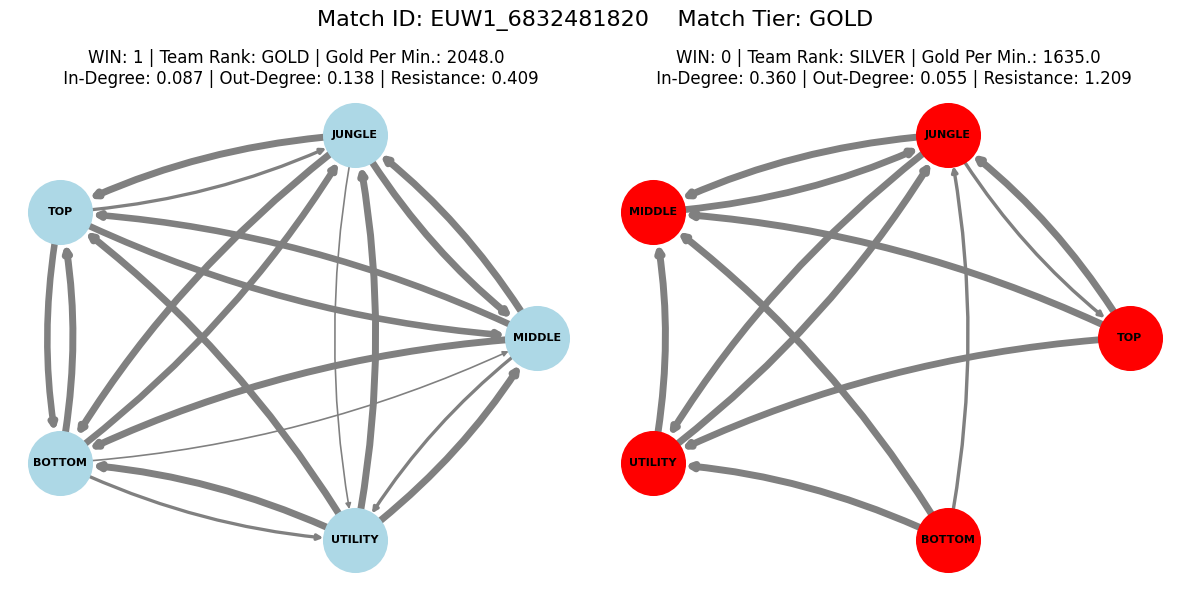

<Figure size 640x480 with 0 Axes>

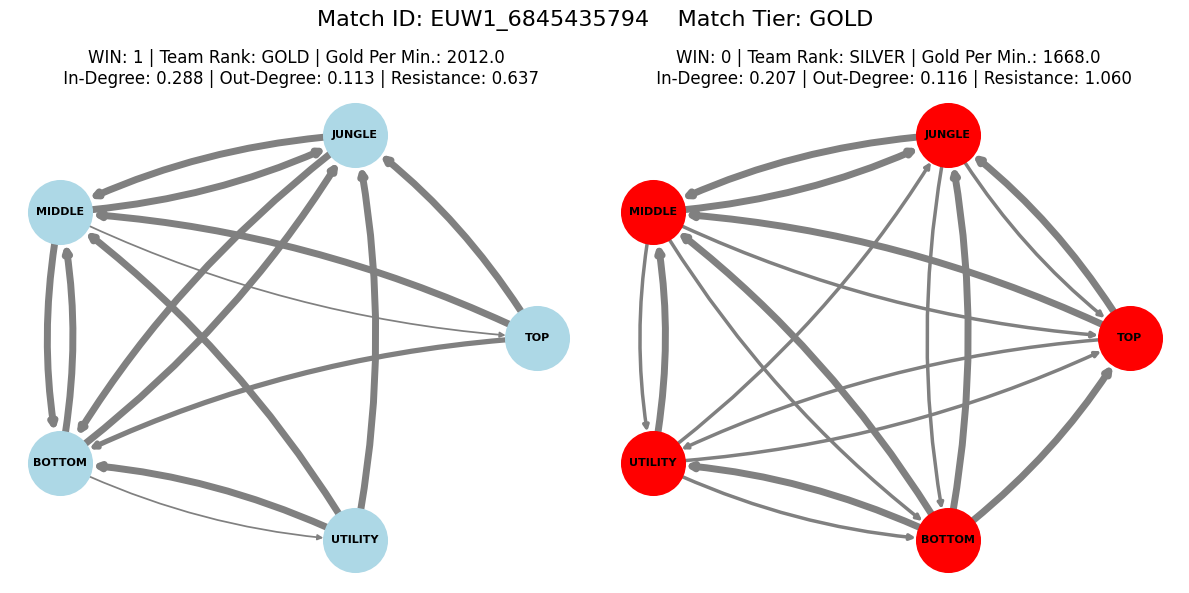

<Figure size 640x480 with 0 Axes>

In [18]:
gameIds = edgesDF['gameId'].tolist()
gameIds = list(set(gameIds))
gameIds = sorted(gameIds)

# use incremental ranges of gameIds to save figure locally
for idx, gameId in enumerate(gameIds[0:2]):
    # team level data of two teams in the same match-up
    blueTeamDF = edgesDF[(edgesDF['gameId'] == gameId) & (edgesDF['teamId'] == 100)]
    blueTeamDF = blueTeamDF[(blueTeamDF['toParticipantId'] >= 1) & (blueTeamDF['toParticipantId'] <= 5)] # additional filter to remove any steals or lease

    redTeamDF = edgesDF[(edgesDF['gameId'] == gameId) & (edgesDF['teamId'] == 200)]
    redTeamDF = redTeamDF[(redTeamDF['toParticipantId'] >= 6) & (redTeamDF['toParticipantId'] <= 10)] # additional filter to remove any steal or lease

    blueTeamEdges = [ min(100 * i, 5) for i in blueTeamDF['normalizedWeight'] ]
    redTeamEdges = [ min(100 * i, 5) for i in redTeamDF['normalizedWeight'] ]

    matchRank = blueTeamDF['gameRank'].iloc[0]
    titleText = f'Match ID: {gameId}    Match Tier: {matchRank}'

    blueTeamAvgRank = blueTeamDF['teamRank'].iloc[0]
    blueTeamWins = blueTeamDF['win'].iloc[0]
    blueTeamGPM = blueTeamDF['teamGPM'].iloc[0]
    blueTeamInD = blueTeamDF['teamIndegreeCentrality'].iloc[0]
    blueTeamOutD = blueTeamDF['teamOutdegreeCentrality'].iloc[0]
    blueTeamRes = blueTeamDF['resistance'].iloc[0]
    
    blueTeamText = f'WIN: {blueTeamWins} | Team Rank: {blueTeamAvgRank} | Gold Per Min.: {blueTeamGPM} \n In-Degree: {blueTeamInD:.3f} | Out-Degree: {blueTeamOutD:.3f} | Resistance: {blueTeamRes:.3f}'
    
    redTeamAvgRank = redTeamDF['teamRank'].iloc[0]
    redTeamWins = redTeamDF['win'].iloc[0]
    redTeamGPM = redTeamDF['teamGPM'].iloc[0]
    redTeamGPM = redTeamDF['teamGPM'].iloc[0]
    redTeamInD = redTeamDF['teamIndegreeCentrality'].iloc[0]
    redTeamOutD = redTeamDF['teamOutdegreeCentrality'].iloc[0]
    redTeamRes = redTeamDF['resistance'].iloc[0]

    redTeamText = f'WIN: {redTeamWins} | Team Rank: {redTeamAvgRank} | Gold Per Min.: {redTeamGPM} \n In-Degree: {redTeamInD:.3f} | Out-Degree: {redTeamOutD:.3f} | Resistance: {redTeamRes:.3f}'

    # create network graph objects
    BTG = nx.from_pandas_edgelist(blueTeamDF, source='fromPlayerPosition', target='toPlayerPosition', edge_attr='normalizedWeight', create_using=nx.MultiDiGraph(directed=True))
    RTG = nx.from_pandas_edgelist(redTeamDF, source='fromPlayerPosition', target='toPlayerPosition', edge_attr='normalizedWeight', create_using=nx.MultiDiGraph(directed=True))

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    posB = nx.circular_layout(BTG)
    posR = nx.circular_layout(RTG)
    
    nx.draw(BTG, pos=posB, ax=axes[0], with_labels=True, node_size=2100, node_color="lightblue", font_size=8, connectionstyle='arc3,rad=0.1', font_weight="bold", arrowsize=8, width=blueTeamEdges, edge_color='gray')
    axes[0].set_title(blueTeamText)

    nx.draw(RTG, pos=posR, ax=axes[1], with_labels=True, node_size=2100, node_color="red", font_size=8, connectionstyle='arc3,rad=0.1', font_weight="bold", arrowsize=8, width=redTeamEdges, edge_color='gray')
    axes[1].set_title(redTeamText)

    # Match title
    plt.suptitle(titleText, fontsize=16)
    plt.tight_layout()
    plt.show()

    # save the figure
    # output_path = f'../graphs/{matchRank}/{gameId}.png'
    # plt.savefig(output_path, format='png', dpi=300)
    # print(f"Image {output_path} saved successfully")
    plt.clf()

In [19]:
print(valid_player_match_details_df.shape)
print(valid_player_match_details_df.columns)

valid_player_match_details_df.head(20)

(34890, 49)
Index(['gameId', 'gameDuration', 'puuid', 'summonerId', 'teamId', 'win',
       'teamPosition', 'champExperience', 'kills', 'assists', 'turretKills',
       'epicMonsterKills', 'visionScore', 'visionWardsBoughtInGame',
       'magicDamageDealtToChampions', 'deaths', 'totalMinionsKilled',
       'timeCCingOthers', 'totalDamageTaken', 'totalHealsOnTeammates',
       'totalTimeSpentDead', 'goldEarned', 'objectivesStolen',
       'objectivesStolenAssists', 'participantId', 'participantsAssisted',
       'towerKillsAssisted', 'monsterKillsAssisted',
       'participantsAssistedWithPressure', 'queueType', 'tier', 'rank',
       'leaguePoints', 'matchPlayerCounts', 'tierRank', 'playerNumericalRank',
       'matchAverageRank', 'teamAverageRank', 'totalTeamGold', 'totalTeamGPM',
       'totalTeamKills', 'totalTeamDeaths', 'totalTeamAssists',
       'totalTeamEpicMonsterKills', 'totalTeamTurretKills',
       'totalTeamVisionScore', 'averageTeamVisionScore',
       'averageTeamChampEx

,gameId,gameDuration,puuid,summonerId,teamId,win,teamPosition,champExperience,kills,assists,...,totalTeamGPM,totalTeamKills,totalTeamDeaths,totalTeamAssists,totalTeamEpicMonsterKills,totalTeamTurretKills,totalTeamVisionScore,averageTeamVisionScore,averageTeamChampExperience,averageTeamMinionsKilled
0,EUW1_7056642171,31.816667,FmFGKQzdKRl6Qib4oPXqyFdK1N-tjRq1gLbBQFdR6a_26W...,MiYNOURyf08JZsI5A4Zinq3xyo_kaRuCb1k8TZ9DrjgNvaU,100,0,TOP,17614,7,2,...,2024.0,39,41,38,1,7,92,18.4,14802.0,140.8
1,EUW1_7056642171,31.816667,jR7nvocTN71FuELZVgpWTONIXgy-7nSMPrzVFa_DJRRmbU...,KHPxd9xptYF-ZyUTkqvUfkxRj4tGdE26HhR5I8jEId4xVss,100,0,JUNGLE,16470,8,11,...,2024.0,39,41,38,1,7,92,18.4,14802.0,140.8
2,EUW1_7056642171,31.816667,GCnGhTyQJOIUMeHqMLJwB-7WAV-1QGCu_APN1uH1A_UMj_...,1s8NLNFEf2P9Z6TKJ9d4owwcvgLQkJDlwEPZ_bYZM3w9qJM,100,0,MIDDLE,13825,10,4,...,2024.0,39,41,38,1,7,92,18.4,14802.0,140.8
3,EUW1_7056642171,31.816667,TpfA9gvsq8JEyzZSo17vMMD_oUWKSQBUl_shjAFlk-ZYhw...,-HnP0u2pXcCBKjbUPvnisjQCwCZa2WkORNDzbJhuzbgy5V0,100,0,BOTTOM,14832,10,9,...,2024.0,39,41,38,1,7,92,18.4,14802.0,140.8
4,EUW1_7056642171,31.816667,TTDHZX3YmznrKvLZ_7rkl1w488cmzLWYPMYxcHpCbc1Ip6...,GSgAg6ZeMEUrbxHyf0U74TRmSlRO0fZpPaMx3Q85b5-dhk...,100,0,UTILITY,11269,4,12,...,2024.0,39,41,38,1,7,92,18.4,14802.0,140.8
5,EUW1_7056642171,31.816667,7fcb27_SWDANPjFD0p0ufrdWVSUP6CGLf2FJti7k1BkRxO...,oJZYTzSOuLVJyCxpArkxxoGLw8bgvKieIU3xAhh84NlQc2...,200,1,TOP,17893,3,9,...,2135.0,41,39,69,4,8,148,29.6,15678.2,128.2
6,EUW1_7056642171,31.816667,4guesNJfLx4xX5_2MJ-eyuPwyv4-hHs4nEZy7LFEomH8gR...,ta-LKOyU7p4HACPwQUu6CoHOfO-WRf0DJzdYVhTDLA1x7Mbf,200,1,JUNGLE,15110,13,13,...,2135.0,41,39,69,4,8,148,29.6,15678.2,128.2
7,EUW1_7056642171,31.816667,XKyg-qijZh7w3vmkgzOhnfg8FIhJ8rF-NKq86sjPLLjekw...,HA3sPzddK8a8KgCKdcBRwnZoj0Oib4P5-SX3eok2W66g5sYg,200,1,MIDDLE,14917,7,14,...,2135.0,41,39,69,4,8,148,29.6,15678.2,128.2
8,EUW1_7056642171,31.816667,etEM9xvolvQnL6GM8xp4oSM39i4WH0CMcDejBvzgJ5FsTl...,OeogFiVyaUB5VeyAdEc31PN8IqwV3qWPO9xdqHJlEIbOYJo,200,1,BOTTOM,16250,16,10,...,2135.0,41,39,69,4,8,148,29.6,15678.2,128.2
9,EUW1_7056642171,31.816667,xVodN3S-576neSL-mZfCY_q1D6dM_TsI9SaLxJQpBZ2C6m...,0VSKog2TXso0PclU_YduzuCP_gjiO-ceuLUw-G_Ua6X7MT...,200,1,UTILITY,14221,2,23,...,2135.0,41,39,69,4,8,148,29.6,15678.2,128.2


In [20]:
# team averaged dataset
teamDF = valid_player_match_details_df[[
    'gameId', 'teamId', 'gameDuration', 'win', 'teamAverageRank', 'matchAverageRank', 
    'totalTeamKills', 'totalTeamDeaths', 'totalTeamAssists', 'totalTeamTurretKills', 'totalTeamEpicMonsterKills', 'totalTeamGold', 'totalTeamGPM', 
    'averageTeamChampExperience', 'averageTeamVisionScore', 'averageTeamMinionsKilled'
    ]]

assistsMapSubsetDF = assistsMapDF[['gameId', 'teamId', 'teamIndegreeCentrality', 'teamOutdegreeCentrality', 'totalTeamAllAssists', 'resistance']]
print(assistsMapSubsetDF.shape)
assistsMapSubsetDF.drop_duplicates(inplace=True)
print(assistsMapSubsetDF.shape)

teamDF = teamDF.merge(assistsMapSubsetDF, on=['gameId', 'teamId'], how='inner')
teamDF

(34890, 6)
(6978, 6)


/tmp/ipykernel_832408/1496706468.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  assistsMapSubsetDF.drop_duplicates(inplace=True)


,gameId,teamId,gameDuration,win,teamAverageRank,matchAverageRank,totalTeamKills,totalTeamDeaths,totalTeamAssists,totalTeamTurretKills,totalTeamEpicMonsterKills,totalTeamGold,totalTeamGPM,averageTeamChampExperience,averageTeamVisionScore,averageTeamMinionsKilled,teamIndegreeCentrality,teamOutdegreeCentrality,totalTeamAllAssists,resistance
0,EUW1_7056642171,100,31.816667,0,13.0,13.8,39,41,38,7,1,64379,2024.0,14802.0,18.4,140.8,0.118852,0.094262,60,1.1017
1,EUW1_7056642171,100,31.816667,0,13.0,13.8,39,41,38,7,1,64379,2024.0,14802.0,18.4,140.8,0.118852,0.094262,60,1.1017
2,EUW1_7056642171,100,31.816667,0,13.0,13.8,39,41,38,7,1,64379,2024.0,14802.0,18.4,140.8,0.118852,0.094262,60,1.1017
3,EUW1_7056642171,100,31.816667,0,13.0,13.8,39,41,38,7,1,64379,2024.0,14802.0,18.4,140.8,0.118852,0.094262,60,1.1017
4,EUW1_7056642171,100,31.816667,0,13.0,13.8,39,41,38,7,1,64379,2024.0,14802.0,18.4,140.8,0.118852,0.094262,60,1.1017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34885,EUW1_7049835170,200,34.466667,0,15.4,14.4,22,37,38,4,2,60183,1747.0,13742.6,35.0,131.8,0.131356,0.131356,53,0.7186
34886,EUW1_7049835170,200,34.466667,0,15.4,14.4,22,37,38,4,2,60183,1747.0,13742.6,35.0,131.8,0.131356,0.131356,53,0.7186
34887,EUW1_7049835170,200,34.466667,0,15.4,14.4,22,37,38,4,2,60183,1747.0,13742.6,35.0,131.8,0.131356,0.131356,53,0.7186
34888,EUW1_7049835170,200,34.466667,0,15.4,14.4,22,37,38,4,2,60183,1747.0,13742.6,35.0,131.8,0.131356,0.131356,53,0.7186


In [21]:
teamDF.drop_duplicates(inplace=True)
print(teamDF.shape)

(6978, 20)


In [22]:
teamDF.to_csv('../perMatchperTeamStats.csv', index=False)

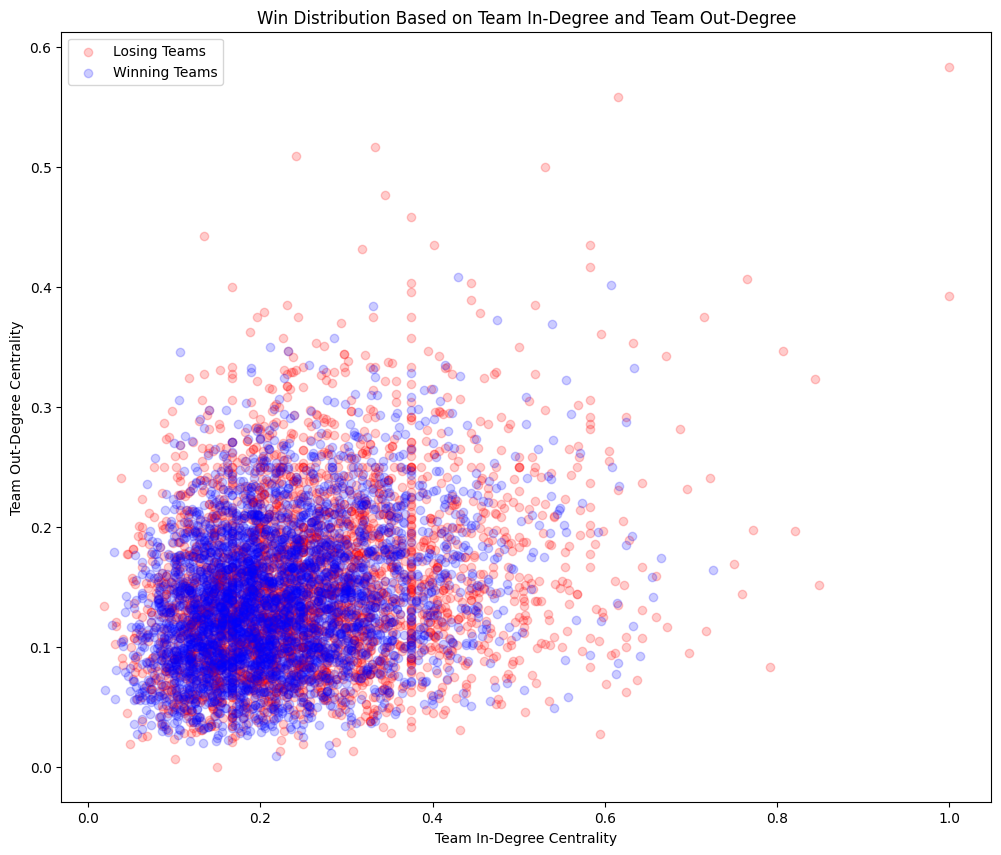

In [23]:
plt.figure(figsize=(12,10))

# Scatter plot for Decision = 0
plt.scatter(teamDF[teamDF['win'] == 0]['teamIndegreeCentrality'], teamDF[teamDF['win'] == 0]['teamOutdegreeCentrality'],
            color='red', label='Losing Teams', alpha=0.2)

# Scatter plot for Decision = 1
plt.scatter(teamDF[teamDF['win'] == 1]['teamIndegreeCentrality'], teamDF[teamDF['win'] == 1]['teamOutdegreeCentrality'],
            color='blue', label='Winning Teams', alpha=0.2)

# Add titles and labels
plt.title('Win Distribution Based on Team In-Degree and Team Out-Degree')
plt.xlabel('Team In-Degree Centrality')
plt.ylabel('Team Out-Degree Centrality')

# Add legend
plt.legend()

# Show plot
plt.show()

## Binary Logistic Regression

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

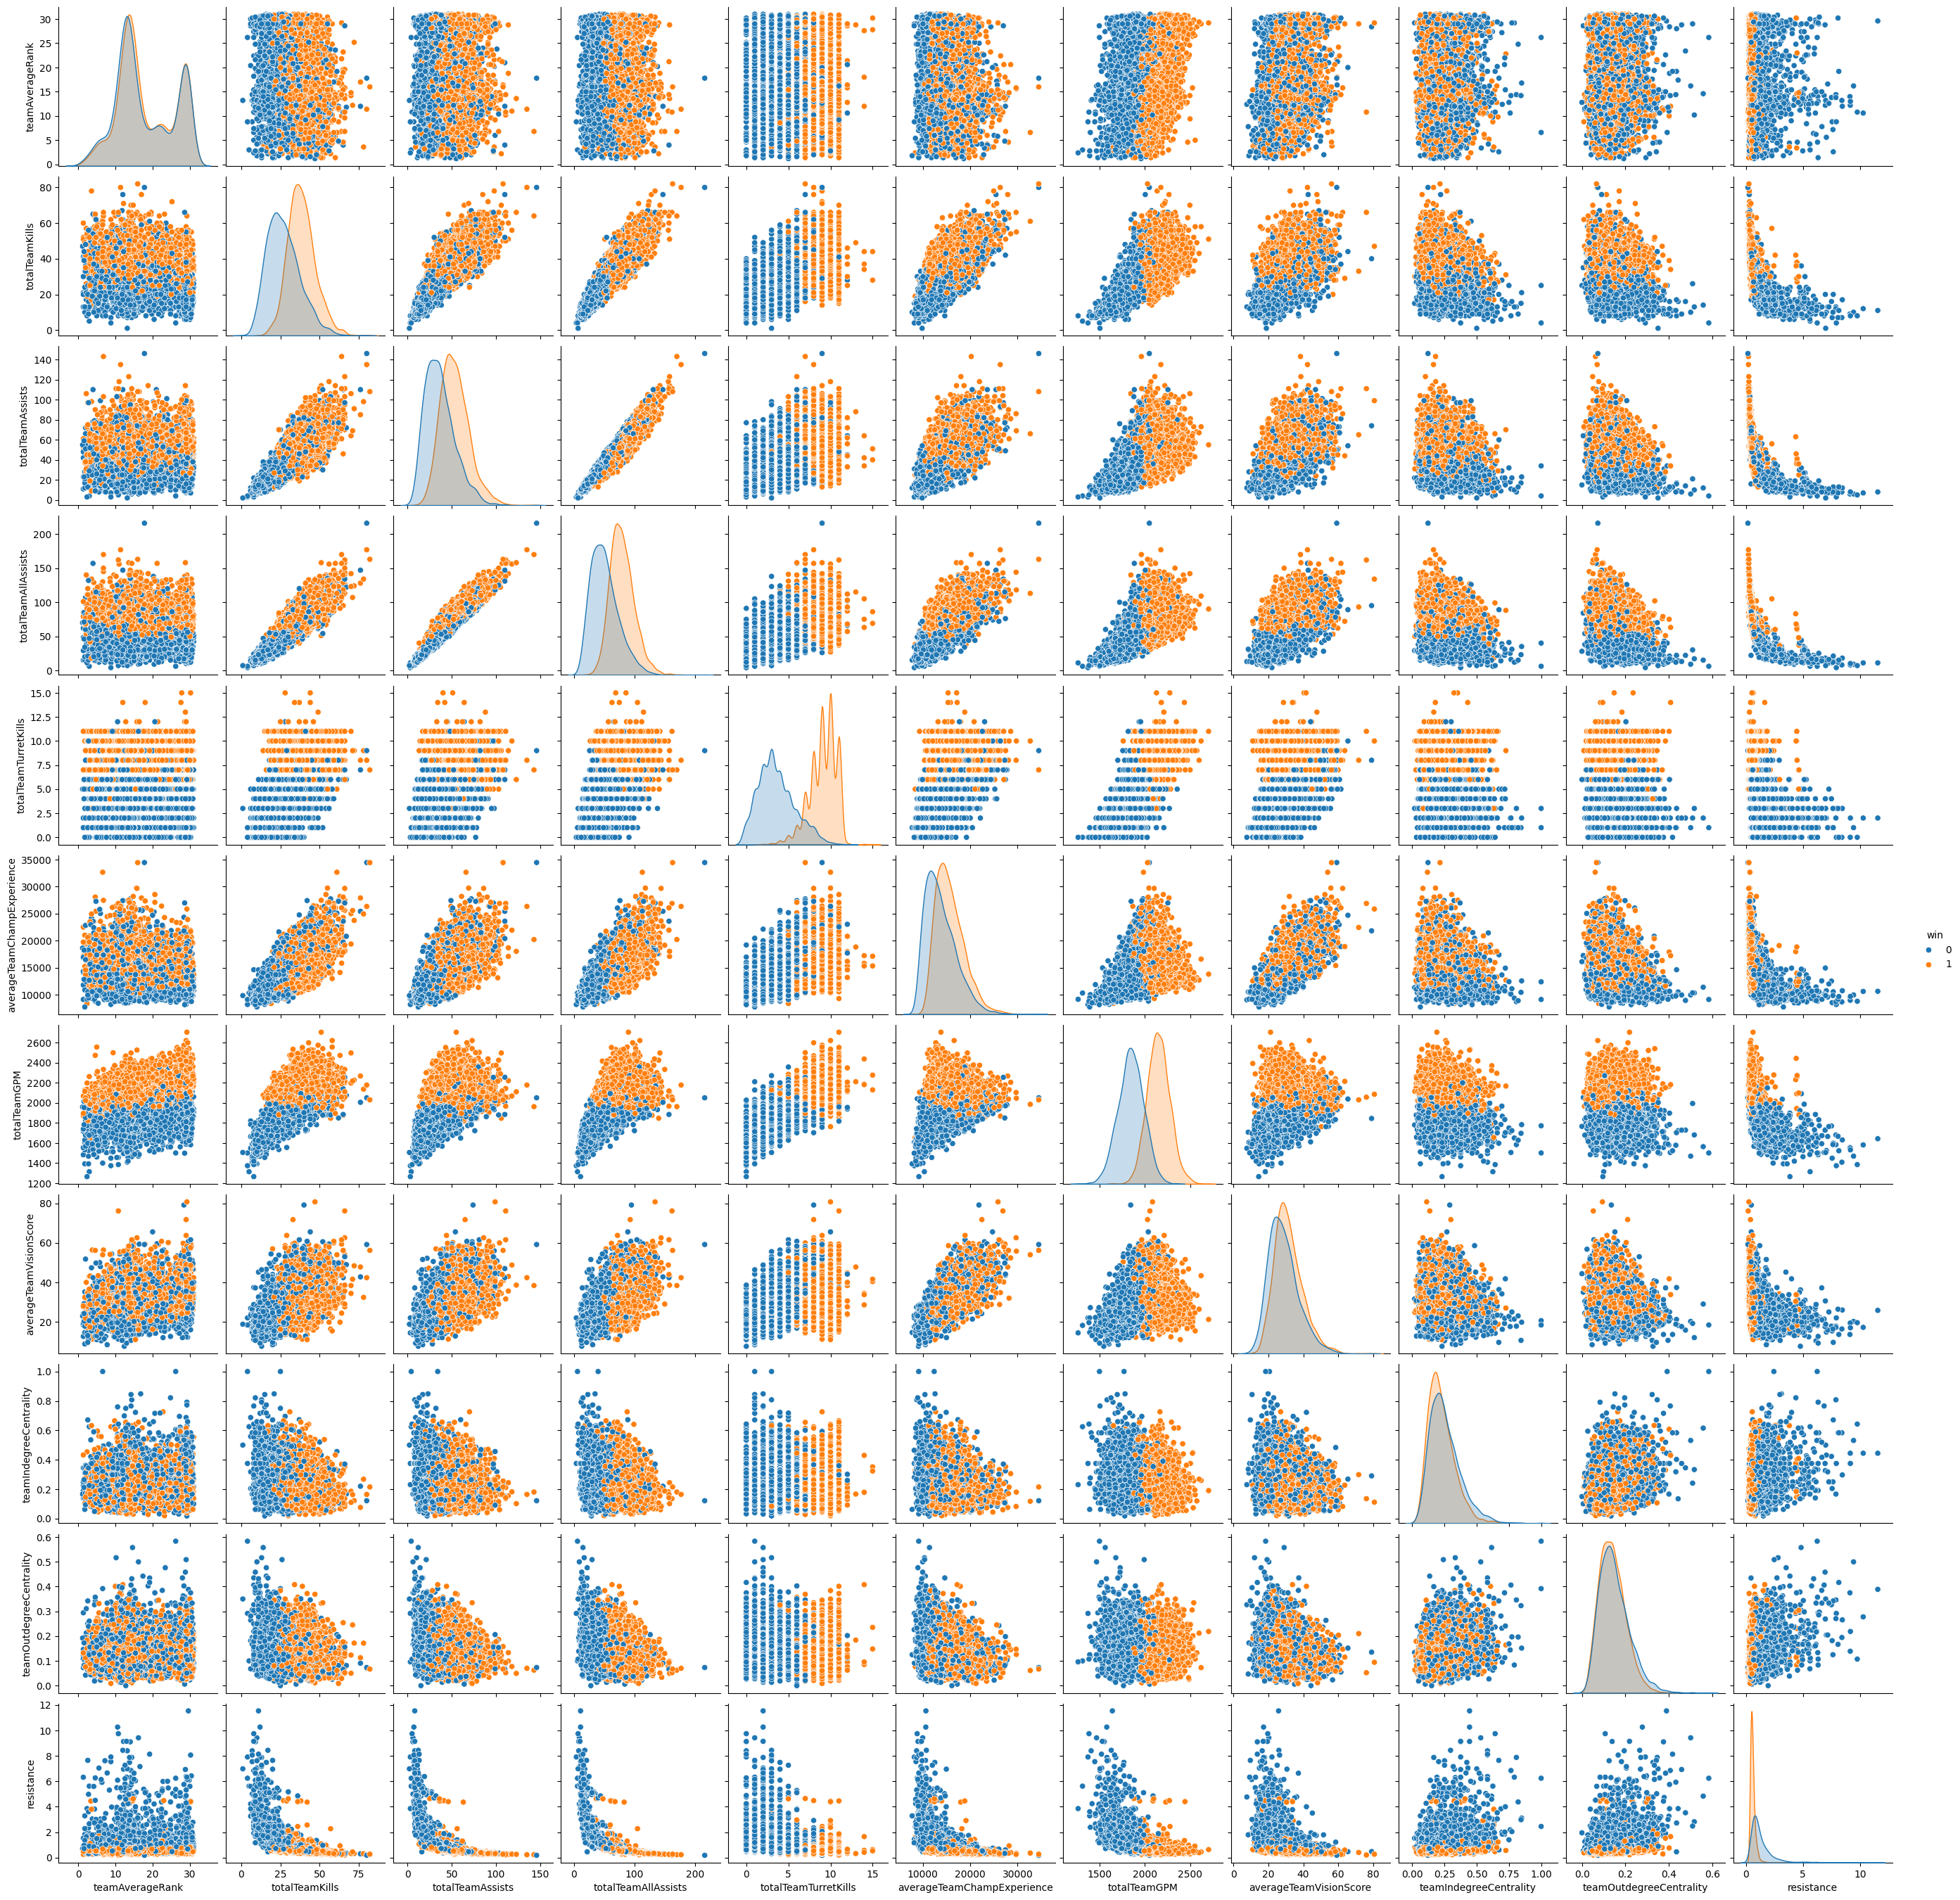

In [25]:
# visualize the data using pairplot
sns.pairplot(teamDF, vars=['teamAverageRank', 'totalTeamKills', 'totalTeamAssists', 'totalTeamAllAssists', 'totalTeamTurretKills', 'averageTeamChampExperience', 'totalTeamGPM', 'averageTeamVisionScore', 'teamIndegreeCentrality', 'teamOutdegreeCentrality', 'resistance'], hue='win')
plt.show()

In [26]:
game_ids = teamDF['gameId'].unique()
train_games, test_games = train_test_split(game_ids, test_size=0.2, random_state=42)

train_df = teamDF[teamDF['gameId'].isin(train_games)]
test_df = teamDF[teamDF['gameId'].isin(test_games)]

X_train = train_df.drop(['gameId', 'teamId', 'gameDuration', 'win'], axis=1)
y_train = train_df['win']

X_test = test_df.drop(['gameId', 'teamId', 'gameDuration', 'win'], axis=1)
y_test = test_df['win']
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5582, 16) (1396, 16) (5582,) (1396,)


In [27]:
# Scaling data features to avoid model skewing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
model = LogisticRegression()

# Fit the model
model.fit(X_train_scaled, y_train)

# Display the coefficients
print('Intercept:', model.intercept_)
print('Coefficients:', model.coef_)

Intercept: [-0.12224558]
Coefficients: [[ 2.51317219 -2.95007258 -0.47615348 -2.05265406  0.18932433  2.86510122
   0.31474937 -1.75906608  2.57789564  2.71323134 -0.13579798 -1.01100707
  -0.02629631 -0.13457106  0.89908628  0.12405086]]


In [29]:
y_pred = model.predict(X_test_scaled)

In [30]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Calculate classification report
class_report = classification_report(y_test, y_pred)

print('Accuracy:', accuracy)
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

Accuracy: 0.9691977077363897
Confusion Matrix:
 [[675  23]
 [ 20 678]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       698
           1       0.97      0.97      0.97       698

    accuracy                           0.97      1396
   macro avg       0.97      0.97      0.97      1396
weighted avg       0.97      0.97      0.97      1396



In [31]:
import statsmodels.api as sm
import pandas as pd

# Add a constant to the model (intercept)
X = teamDF[['totalTeamKills', 'totalTeamAssists', 'totalTeamTurretKills', 'averageTeamChampExperience', 'totalTeamGPM', 'teamIndegreeCentrality', 'teamOutdegreeCentrality', 'resistance']]
X = sm.add_constant(X)

y = teamDF['win']

# Fit the logistic regression model
model = sm.Logit(y, X)
result = model.fit()

# Print the summary of the model
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.163798
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:                 6978
Model:                          Logit   Df Residuals:                     6969
Method:                           MLE   Df Model:                            8
Date:                Tue, 13 Aug 2024   Pseudo R-squ.:                  0.7637
Time:                        20:00:27   Log-Likelihood:                -1143.0
converged:                       True   LL-Null:                       -4836.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        -24.2561      1.263    -19.205      0.000     -